# 01_EDA: Indoor Environmental Sensor Data

**Goal:** Perform basic exploratory data analysis (EDA) for indoor environmental sensor readings, parse timestamps, merge with device metadata (location types), and visualize key distributions and time-series behavior.

This notebook is intentionally robust to small column-name differences (e.g., `rxtimestamputc` vs `timestamp`, `Type of location` vs `location_type`).

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## Load data from Excel

Read the Excel workbook from `data/` and identify the sensor sheet and metadata sheet. This cell prints sheet names and row counts to verify that we loaded the expected tables.

In [24]:
data_dir = Path('..') / 'data'
excel_files = sorted(data_dir.glob('*.xlsx'))
if not excel_files:
    raise FileNotFoundError(f"No .xlsx file found in {data_dir.resolve()}")

xlsx_path = excel_files[0]
print('Using workbook:', xlsx_path.name)

all_sheets = pd.read_excel(xlsx_path, sheet_name=None)
print('Sheets found:', list(all_sheets.keys()))

for n, df in all_sheets.items():
    print(f' - {n}: {len(df):,} rows, columns: {len(df.columns)}')

Using workbook: data.xlsx
Sheets found: ['15.08.2025-15.09.2025', 'AteccID-Location Mapping']
 - 15.08.2025-15.09.2025: 1,048,575 rows, columns: 33
 - AteccID-Location Mapping: 33 rows, columns: 8


In [25]:
# helper for robust column detection
def find_col(cols, candidates):
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

sensor_df = None
meta_df = None
sensor_sheet = None
meta_sheet = None

for name, df in all_sheets.items():
    normalized = ' '.join(c.lower() for c in df.columns.astype(str))
    if any(k in normalized for k in ['temp', 'co2', 'tvoc', 'aqi', 'occupancy', 'rxtimestamputc', 'timestamp']):
        if sensor_df is None or len(df) > len(sensor_df):
            sensor_df = df.copy()
            sensor_sheet = name
    if any(k in normalized for k in ['type of location', 'type', 'location', 'x', 'y', 'metadata', 'device']):
        if meta_df is None or len(df) < len(sensor_df if sensor_df is not None else df):
            meta_df = df.copy()
            meta_sheet = name

if sensor_df is None or meta_df is None:
    print('Could not automatically identify sensor and metadata sheets. Using first two sheets as fallback.')
    names = list(all_sheets.keys())
    if len(names) >= 2:
        sensor_sheet = names[0]
        meta_sheet = names[1]
        sensor_df = all_sheets[sensor_sheet].copy()
        meta_df = all_sheets[meta_sheet].copy()
    else:
        raise RuntimeError('Workbook must have at least two sheets.')

print('Selected sensor sheet:', sensor_sheet)
print('Selected metadata sheet:', meta_sheet)

Selected sensor sheet: 15.08.2025-15.09.2025
Selected metadata sheet: AteccID-Location Mapping


In [26]:
sensor_df.head()

,sensorlocation_id,rxtimestamputc,physicalsensorid,ateccid,devicetype2_name,building_id,capacity_people,timezone_name,min_occupant,max_occupant,total_occupant,tvoc,co2,temp,pressure,lux,snd,combined_occupancy,humid,bearing,aqi1,aqi2,aqi3,blue_relative,clear_relative,green_relative,no2,o3,red_relative,voc_resistance,avg_occupant,occupancy1,occupancy2
0,4750c2eb-a551-4de8-b927-f3d311e89666,2025-08-15 00:00:03.071,70B3D56EF001016E,012335521BE30BEE01,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,8,Europe/London,0,0,0,5,455,26.700,1010,0,35,0,60.236,59,157,188,0,0,1,0,1,0,0,336891,0,0.000,0
1,64d673f4-45cc-474d-9196-a6c0120b4456,2025-08-15 00:00:03.084,70B3D56EF001029A,0123874CF37F81C401,HX2 MV Platinum,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,6,Europe/London,0,0,0,6,481,26.200,1009,0,32,0,64.172,56,164,197,26,0,0,0,26,4,0,1281070,0,0.000,0
2,6daaab7d-9341-43ab-b6fd-16cf1d4f7aef,2025-08-15 00:00:08.426,70B3D56EF0010197,0123BE9659A3289001,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,8,Europe/London,0,0,0,1,506,26.000,1010,0,33,0,62.896,3,105,176,0,0,0,0,0,0,0,526617,0,0.000,0
3,f3490f52-3aca-441d-989a-4b09db5eb18c,2025-08-15 00:00:15.640,70B3D56EF001058D,0123094969F1AA9D01,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,10,Europe/London,0,0,0,1,495,25.800,1010,0,33,0,62.022,349,106,179,38,0,0,0,40,0,0,543909,0,0.000,0
4,413ab1ba-21a8-4b53-972c-5cfc126f5ea9,2025-08-15 00:00:16.960,70B3D56EF00100DB,0123EA796859295001,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,16,Europe/London,0,0,0,4,456,26.000,1010,0,35,0,62.480,70,150,191,0,0,0,0,0,0,0,507775,0,0.000,0


In [27]:
meta_df.head()

,Device Location,AteccID,X-coordinate,Y-coordinate,Bearing (°),Rotation (°),Height (m),Type of location
0,1,012353A0D79B8B6501,1994.200,-2564.700,18.910,270,2.860,Open Space
1,2,0123C71FFE39D2DF01,2606.200,-2564.700,4.910,270,2.860,Open Space
2,3,0123FCA88283696901,3222.200,-2564.700,6.020,270,2.860,Open Space
3,4,0123B9C3BE0C085E01,4038.200,-2564.700,11.100,270,2.860,Open Space
4,5,0123C2ABF23B69DA01,4650.200,-2564.700,351.590,270,2.860,Open Space


## Parse timestamps and merge metadata

Convert the timestamp column to datetime, set it as an index (optional), and merge sensor readings with device metadata by device ID.

In [28]:
# Normalize column names for robustness
sensor_df = sensor_df.rename(columns=lambda s: str(s).strip())
meta_df = meta_df.rename(columns=lambda s: str(s).strip())

# Identify the key columns in sensor table
sensor_id_col = find_col(sensor_df.columns, ['ateccid', 'device_id', 'device', 'id'])
timestamp_col = find_col(sensor_df.columns, ['rxtimestamputc', 'timestamp', 'time', 'datetime', 'ts'])
temp_col = find_col(sensor_df.columns, ['temp', 'temperature'])
co2_col = find_col(sensor_df.columns, ['co2', 'carbon_dioxide'])
tvoc_col = find_col(sensor_df.columns, ['tvoc'])
aqi_col = find_col(sensor_df.columns, ['aqi1', 'aqi', 'aqi_1'])
occupancy_col = find_col(sensor_df.columns, ['combined_occupancy', 'occupancy'])

device_id_col_meta = find_col(meta_df.columns, ['ateccid', 'device_id', 'device', 'id'])
x_col = find_col(meta_df.columns, ['x', 'X', 'x_coord', 'x_coordinate', 'X-coordinate'])
y_col = find_col(meta_df.columns, ['y', 'Y', 'y_coord', 'y_coordinate', 'Y-coordinate'])
location_type_col = find_col(meta_df.columns, ['Type of location', 'type_of_location', 'type', 'location_type', 'location'])

print('Mapped sensor id:', sensor_id_col)
print('Mapped timestamp:', timestamp_col)
print('Mapped metadata id:', device_id_col_meta)
print('Mapped location type:', location_type_col)
print('Mapped X/Y:', x_col, y_col)

if timestamp_col is None:
    raise ValueError('Could not find a timestamp-like column in sensor data. Please check column names.')

sensor_df[timestamp_col] = pd.to_datetime(sensor_df[timestamp_col], errors='coerce', utc=True)
sensor_df = sensor_df.sort_values(timestamp_col)
sensor_df = sensor_df.rename(columns={timestamp_col: 'timestamp_utc'})

if sensor_id_col is not None and device_id_col_meta is not None and sensor_id_col != device_id_col_meta:
    sensor_df = sensor_df.rename(columns={sensor_id_col: 'ateccid'})
    meta_df = meta_df.rename(columns={device_id_col_meta: 'ateccid'})
elif sensor_id_col is not None:
    sensor_df = sensor_df.rename(columns={sensor_id_col: 'ateccid'})
elif device_id_col_meta is not None:
    meta_df = meta_df.rename(columns={device_id_col_meta: 'ateccid'})

meta_rename = {}
if location_type_col is not None:
    meta_rename[location_type_col] = 'location_type'
if x_col is not None:
    meta_rename[x_col] = 'X'
if y_col is not None:
    meta_rename[y_col] = 'Y'
if meta_rename:
    meta_df = meta_df.rename(columns=meta_rename)

# Merge sensor and metadata by device ID
merged_df = pd.merge(sensor_df.reset_index(), meta_df, on='ateccid', how='left')
merged_df = merged_df.set_index('timestamp_utc')

# Quick sanity checks after merge
print('Merged shape:', merged_df.shape)
print('Null metadata rows (ateccid):', merged_df['ateccid'].isna().sum() if 'ateccid' in merged_df.columns else 'N/A')
print('Metadata columns found:', [c for c in merged_df.columns if c in ['location_type','X','Y']])

# Save key data artifacts for reuse in later notebooks
out_dir = Path('..') / 'data'
out_dir.mkdir(parents=True, exist_ok=True)

sensor_df_path = out_dir / 'sensor_table.csv'
meta_df_path = out_dir / 'metadata_table.csv'
merged_path = out_dir / 'merged_sensor_metadata.csv'

sensor_df.to_csv(sensor_df_path, index=False)
meta_df.to_csv(meta_df_path, index=False)
merged_df.reset_index().to_csv(merged_path, index=False)

print('Saved sensor table to:', sensor_df_path)
print('Saved metadata table to:', meta_df_path)
print('Saved merged data to:', merged_path)

merged_df.head()

Mapped sensor id: ateccid
Mapped timestamp: rxtimestamputc
Mapped metadata id: AteccID
Mapped location type: Type of location
Mapped X/Y: X-coordinate Y-coordinate
Merged shape: (1048575, 40)
Null metadata rows (ateccid): 0
Metadata columns found: ['X', 'Y', 'location_type']
Saved sensor table to: ../data/sensor_table.csv
Saved metadata table to: ../data/metadata_table.csv
Saved merged data to: ../data/merged_sensor_metadata.csv


,index,sensorlocation_id,physicalsensorid,ateccid,devicetype2_name,building_id,capacity_people,timezone_name,min_occupant,max_occupant,total_occupant,tvoc,co2,temp,pressure,lux,snd,combined_occupancy,humid,bearing,aqi1,aqi2,aqi3,blue_relative,clear_relative,green_relative,no2,o3,red_relative,voc_resistance,avg_occupant,occupancy1,occupancy2,Device Location,X,Y,Bearing (°),Rotation (°),Height (m),location_type
timestamp_utc,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-08-15 00:00:03.071000+00:00,0,4750c2eb-a551-4de8-b927-f3d311e89666,70B3D56EF001016E,012335521BE30BEE01,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,8,Europe/London,0,0,0,5,455,26.700,1010,0,35,0,60.236,59,157,188,0,0,1,0,1,0,0,336891,0,0.000,0,21,2434.700,-3752.500,53.910,180,2.860,Kitchen
2025-08-15 00:00:03.084000+00:00,1,64d673f4-45cc-474d-9196-a6c0120b4456,70B3D56EF001029A,0123874CF37F81C401,HX2 MV Platinum,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,6,Europe/London,0,0,0,6,481,26.200,1009,0,32,0,64.172,56,164,197,26,0,0,0,26,4,0,1281070,0,0.000,0,19,3789.300,-3281.100,51.580,180,2.860,Open Space
2025-08-15 00:00:08.426000+00:00,2,6daaab7d-9341-43ab-b6fd-16cf1d4f7aef,70B3D56EF0010197,0123BE9659A3289001,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,8,Europe/London,0,0,0,1,506,26.000,1010,0,33,0,62.896,3,105,176,0,0,0,0,0,0,0,526617,0,0.000,0,10,8478.200,-2564.700,2.400,270,2.860,Open Space
2025-08-15 00:00:15.640000+00:00,3,f3490f52-3aca-441d-989a-4b09db5eb18c,70B3D56EF001058D,0123094969F1AA9D01,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,10,Europe/London,0,0,0,1,495,25.800,1010,0,33,0,62.022,349,106,179,38,0,0,0,40,0,0,543909,0,0.000,0,13,8470.800,-4091.600,348.860,270,2.860,Open Space
2025-08-15 00:00:16.960000+00:00,4,413ab1ba-21a8-4b53-972c-5cfc126f5ea9,70B3D56EF00100DB,0123EA796859295001,HX2 MV Standard,2f8ddbf6-7f14-4a7b-bd00-9c2410d55ee6,16,Europe/London,0,0,0,4,456,26.000,1010,0,35,0,62.480,70,150,191,0,0,0,0,0,0,0,507775,0,0.000,0,23,1114.200,-6362.000,65.430,180,2.860,Canteen


## EDA: Info, Describe, Missing values
Report dataset structure and missing values before plotting.

In [29]:
print('--- info ---')
merged_df.info()

numeric_cols = [c for c in merged_df.columns if pd.api.types.is_numeric_dtype(merged_df[c])]
print('\nNumeric columns:', numeric_cols)
display(merged_df[numeric_cols].describe().T)

missing_pct = merged_df.isna().mean() * 100
display(missing_pct.sort_values(ascending=False).to_frame('missing_pct'))

--- info ---
<class 'pandas.DataFrame'>
DatetimeIndex: 1048575 entries, 2025-08-15 00:00:03.071000+00:00 to 2025-09-15 23:59:57.655000+00:00
Data columns (total 40 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   index               1048575 non-null  int64  
 1   sensorlocation_id   1048575 non-null  str    
 2   physicalsensorid    1048575 non-null  str    
 3   ateccid             1048575 non-null  str    
 4   devicetype2_name    1048575 non-null  str    
 5   building_id         1048575 non-null  str    
 6   capacity_people     1048575 non-null  int64  
 7   timezone_name       1048575 non-null  str    
 8   min_occupant        1048575 non-null  int64  
 9   max_occupant        1048575 non-null  int64  
 10  total_occupant      1048575 non-null  int64  
 11  tvoc                1048575 non-null  int64  
 12  co2                 1048575 non-null  int64  
 13  temp                1048575 non-null  float64
 14  press

,count,mean,std,min,25%,50%,75%,max
index,1048575.000,524287.000,302697.674,0.000,262143.500,524287.000,786430.500,1048574.000
capacity_people,1048575.000,8.062,3.278,4.000,6.000,8.000,8.000,16.000
min_occupant,1048575.000,0.248,0.894,0.000,0.000,0.000,0.000,10.000
max_occupant,1048575.000,0.248,0.894,0.000,0.000,0.000,0.000,10.000
total_occupant,1048575.000,0.248,0.894,0.000,0.000,0.000,0.000,10.000
tvoc,1048575.000,0.991,1.942,0.000,0.000,1.000,1.000,176.000
co2,1048575.000,518.806,111.779,400.000,453.000,486.000,538.000,2697.000
temp,1048575.000,23.329,2.562,3.400,22.000,23.800,24.900,33.200
pressure,1048575.000,994.097,12.517,973.000,983.000,991.000,1007.000,1018.000
lux,1048575.000,122.486,196.811,0.000,9.000,25.000,191.000,5440.000


,missing_pct
occupancy1,0.011
index,0.000
voc_resistance,0.000
aqi3,0.000
blue_relative,0.000
clear_relative,0.000
green_relative,0.000
no2,0.000
o3,0.000
red_relative,0.000


## Distribution plots for key environmental variables
Plot histograms with KDE for temperature, CO2, TVOC, AQI, and occupancy if present.

In [30]:
key_metrics = ['temp','temperature','co2','tvoc','aqi1','aqi','combined_occupancy','occupancy', 'humid', 'location_type', 'lux', 'snd']

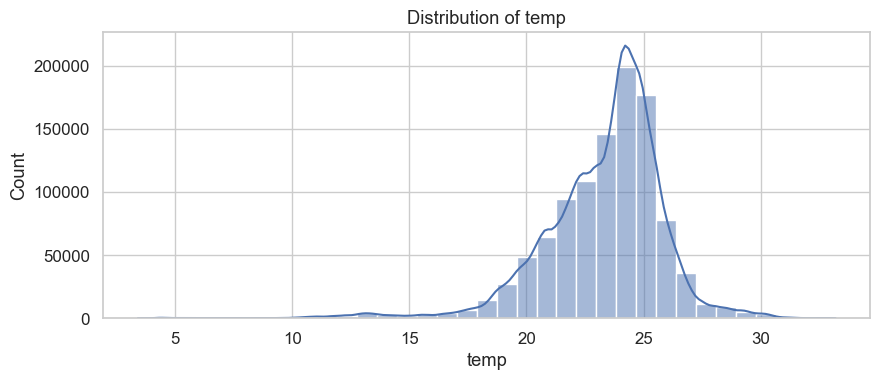

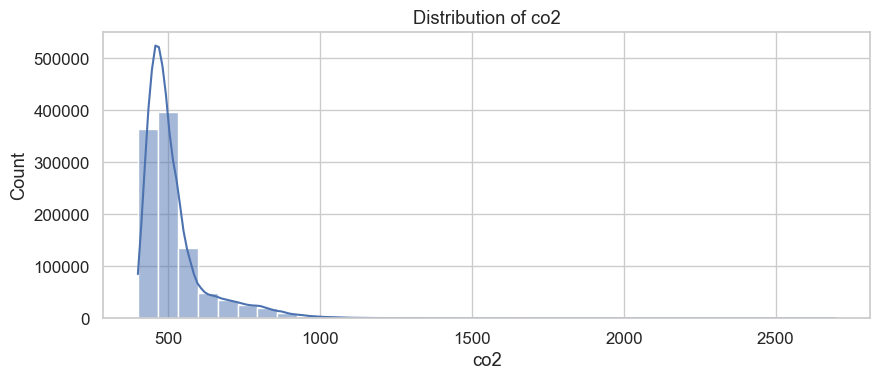

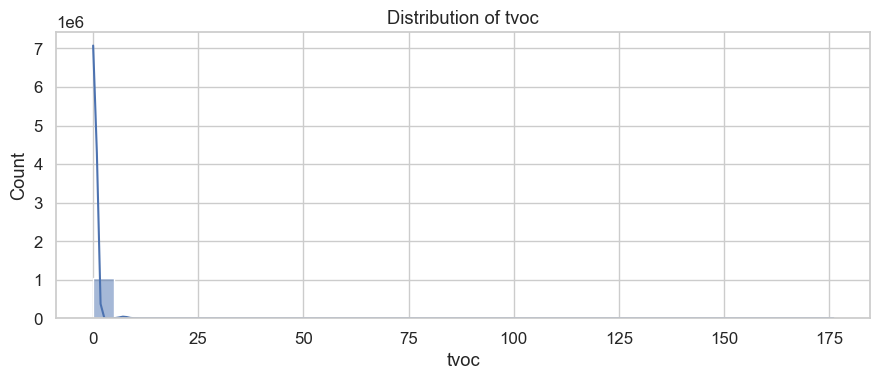

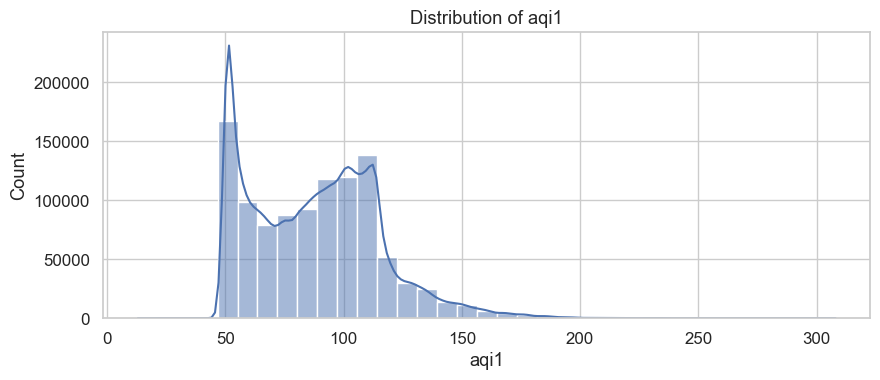

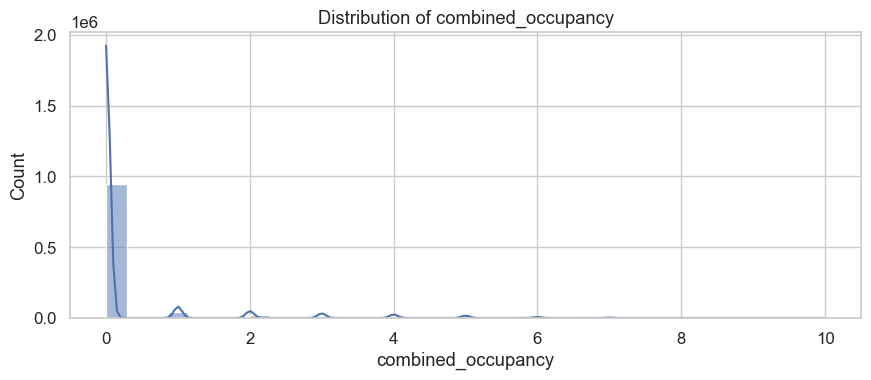

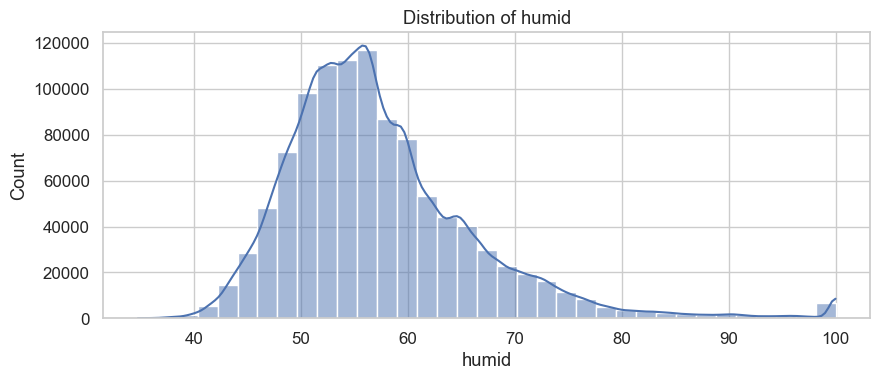

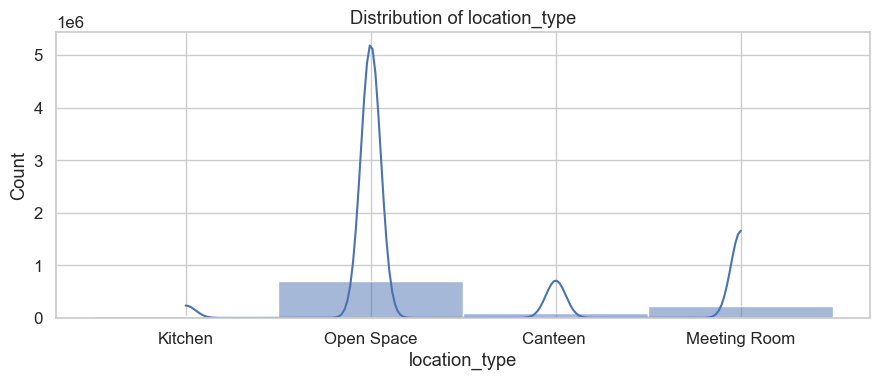

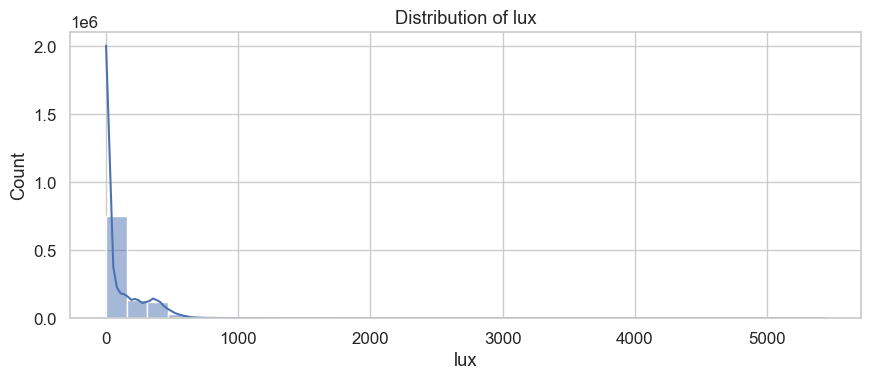

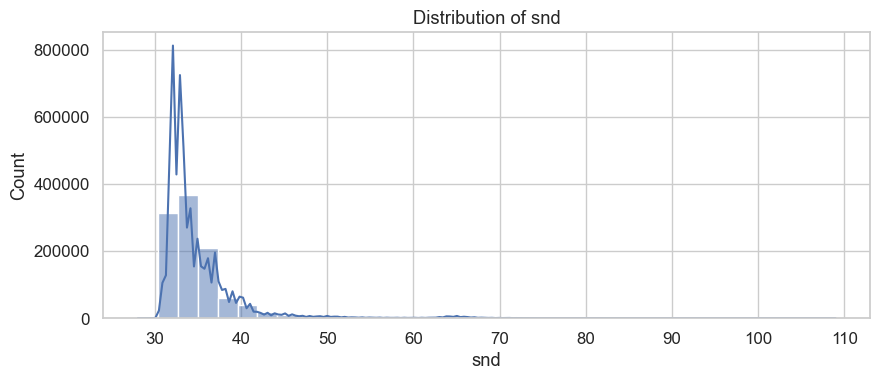

In [31]:
plot_cols = [c for c in key_metrics if c in merged_df.columns]
for c in plot_cols:
    plt.figure(figsize=(9, 4))
    sns.histplot(merged_df[c].dropna(), kde=True, bins=35)
    plt.title(f'Distribution of {c}')
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## Time-series patterns by location type
Compare one sample device per location type using a selected sensor variable.

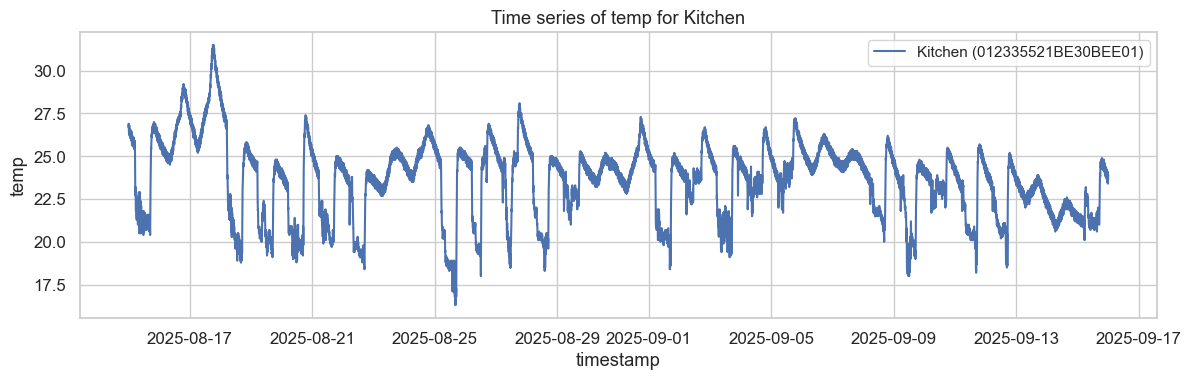

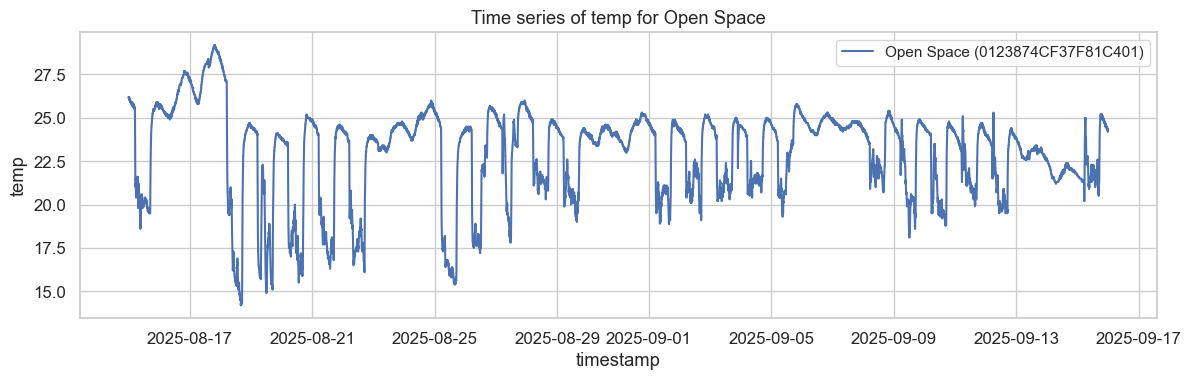

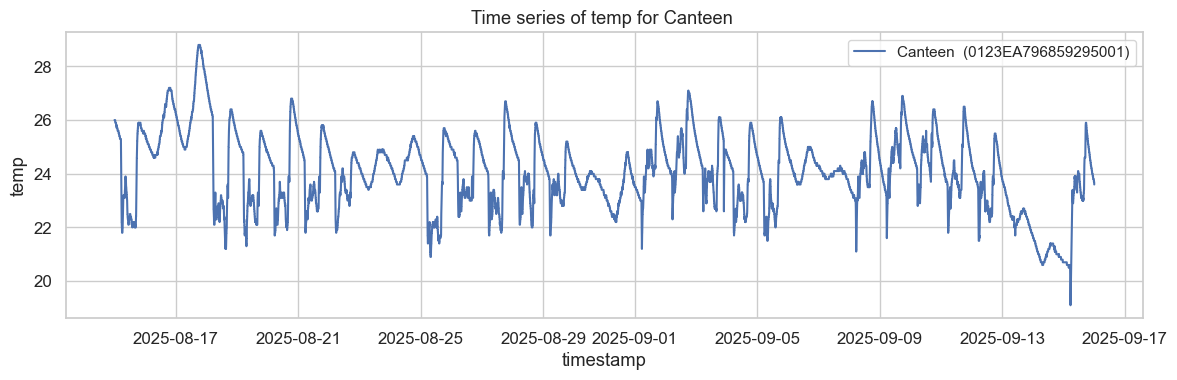

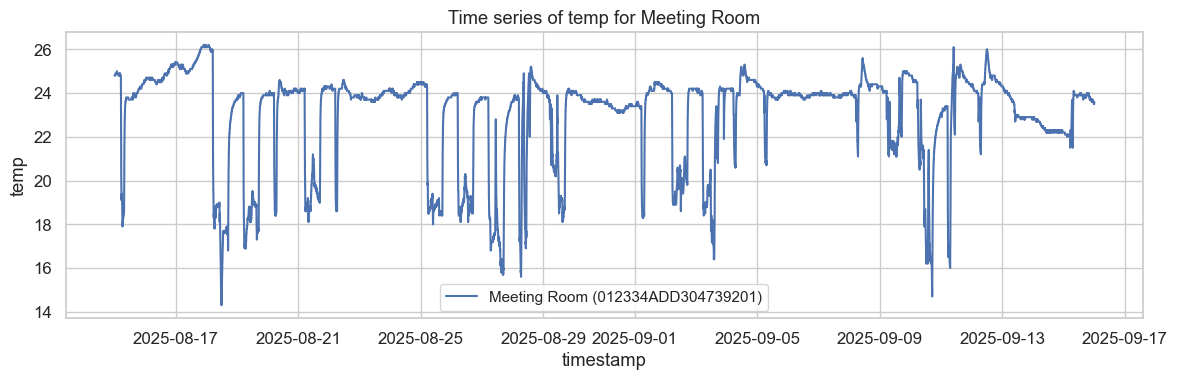

In [32]:
location_col = next((c for c in merged_df.columns if 'location_type' in str(c).lower()), None)
if location_col is not None:
    ts_col = next((c for c in key_metrics if c in merged_df.columns), None)
    if ts_col is not None:
        unique_locations = merged_df[location_col].dropna().unique()
        for lt in unique_locations:
            subset = merged_df[merged_df[location_col] == lt].dropna(subset=[ts_col])
            if subset.empty:
                continue
            dev = subset['ateccid'].dropna().unique()[:1] if 'ateccid' in subset.columns else []
            if len(dev) == 0 and 'ateccid' in subset.columns:
                continue
            s = subset[subset['ateccid'] == dev[0]].sort_index() if 'ateccid' in subset.columns else subset.sort_index()
            plt.figure(figsize=(12, 4))
            plt.plot(s.index, s[ts_col], label=f'{lt} ({dev[0]})' if len(dev) > 0 else lt)
            plt.title(f'Time series of {ts_col} for {lt}')
            plt.xlabel('timestamp')
            plt.ylabel(ts_col)
            plt.legend(fontsize='small')
            plt.tight_layout()
            plt.show()
    else:
        print('No time-series feature found for location comparison.')
else:
    print('No location metadata column available for time-series comparison.')

## Floor layout scatter (X vs Y)
Plot device coordinates from metadata and color by location type.

In [ ]:
loc_col = next((c for c in merged_df.columns if 'location_type' in str(c).lower()), None)
if set(['X','Y']).issubset(merged_df.columns) and loc_col is not None:
    layout_df = merged_df.dropna(subset=['X','Y',loc_col])
    plt.figure(figsize=(9, 7))
    sns.scatterplot(data=layout_df, x='X', y='Y', hue=loc_col, palette='tab10', s=80)
    plt.title('Device floor layout: X vs Y')
    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Need X,Y and a location-type column for floor layout scatter.')

## Sensor Isolation (Manual floor-plan knowledge)

Some sensors may be isolated or unreliable based on floor-plan knowledge (e.g., deployment errors, physical obstructions, or measurement artifacts). 

The `is_sensor_isolated` column is **manually set** based on domain knowledge and will be used later in the distance matrix to mark isolated sensors with a distance of `-1` to all other sensors, effectively excluding them from neighbourhood selection.

Fill in the `isolated_ids` list below with sensor IDs known to be isolated, then the code will apply this labeling to the `devices` DataFrame.

In [33]:
# Extract devices table from metadata and initialize sensor isolation column
devices = meta_df[['ateccid', 'X', 'Y', 'location_type']].copy()

# Ensure ateccid is treated as string
devices['ateccid'] = devices['ateccid'].astype(str)

# Initialize is_sensor_isolated column to False for all sensors
devices['is_sensor_isolated'] = False

# Fill in with real isolated sensor IDs based on floor-plan knowledge
isolated_ids = [
    "012335521BE30BEE01", "0123A094278ECD7201", "012334ADD304739201", "012359DE241D660101", "012323B65191BA0F01", "0123E443E9C07E5301", "01234D0CF531B49F01", "0123DB7DEC68B8D301", "0123067D065E709F01", "01231F0ED9653CF801"
]

# Mark isolated sensors
devices.loc[devices['ateccid'].isin(isolated_ids), 'is_sensor_isolated'] = True

# Summary
n_isolated = devices['is_sensor_isolated'].sum()
n_total = len(devices)
n_active = n_total - n_isolated

print(f'Sensor isolation summary:')
print(f'  Total sensors: {n_total}')
print(f'  Isolated: {n_isolated}')
print(f'  Active: {n_active}')

if n_isolated > 0:
    print(f'\nIsolated sensors:')
    display(devices[devices['is_sensor_isolated']][['ateccid', 'X', 'Y', 'location_type', 'is_sensor_isolated']])
else:
    print('\nNo isolated sensors marked.')

Sensor isolation summary:
  Total sensors: 33
  Isolated: 10
  Active: 23

Isolated sensors:


,ateccid,X,Y,location_type,is_sensor_isolated
20,012335521BE30BEE01,2434.700,-3752.500,Kitchen,True
21,0123A094278ECD7201,3232.500,-5203.600,Open Space,True
23,012334ADD304739201,4852.600,-6482.200,Meeting Room,True
24,012359DE241D660101,5300.400,-7099.000,Meeting Room,True
25,012323B65191BA0F01,4852.600,-6882.100,Meeting Room,True
28,0123E443E9C07E5301,4716.300,-8180.000,Meeting Room,True
29,01234D0CF531B49F01,5318.500,-7920.000,Open Space,True
30,0123DB7DEC68B8D301,5908.500,-7539.300,Meeting Room,True
31,0123067D065E709F01,6721.700,-7539.300,Meeting Room,True
32,01231F0ED9653CF801,7727.000,-8405.000,Meeting Room,True


In [34]:
# Add is_sensor_isolated column to meta_df
meta_df['is_sensor_isolated'] = meta_df['ateccid'].isin(isolated_ids)

# Also add to merged_df (after merge)
merged_df = pd.merge(sensor_df.reset_index(), meta_df, on='ateccid', how='left')
merged_df = merged_df.set_index('timestamp_utc')

# Save updated metadata to CSV
meta_df.to_csv(meta_df_path, index=False)
merged_df.reset_index().to_csv(merged_path, index=False)
print(f"Updated {meta_df_path} and {merged_path} with is_sensor_isolated column")
print(f"Total sensors marked as isolated in {meta_df_path}: {meta_df['is_sensor_isolated'].sum()}")
print(f"Total sensors marked as isolated in {merged_path}: {merged_df['is_sensor_isolated'].sum()}")

Updated ../data/metadata_table.csv and ../data/merged_sensor_metadata.csv with is_sensor_isolated column
Total sensors marked as isolated in ../data/metadata_table.csv: 10
Total sensors marked as isolated in ../data/merged_sensor_metadata.csv: 317956
